In [9]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
opto_thresh = 2.7
control_thresh = 2.9

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [10]:
pre_opto = ['AE_344','AE_346','AE_367']
pre_control = ['AE_350','AE_359','AE_418','AE_498','AE_351']

all_animals = np.concatenate([pre_opto, pre_control])

In [11]:
df = pd.read_csv(os.path.join('..','..','Source Data Files','Figure 3q.csv'))

In [12]:
df

,Unnamed: 0,animal,session,cluster ID,learning phase,nontarget evoked FR
0,0,AE_344,AE_344_10_opto_AC.pickle,15,3,6.344086
1,1,AE_344,AE_344_10_opto_AC.pickle,27,3,-10.215054
2,2,AE_344,AE_344_10_opto_AC.pickle,46,3,8.707483
3,3,AE_344,AE_344_10_opto_AC.pickle,59,3,6.021505
4,4,AE_344,AE_344_10_opto_AC.pickle,60,3,24.086022
...,...,...,...,...,...,...
944,944,AE_498,AE_498_5_opto_control_AC.pickle,275,pre expert,21.451613
945,945,AE_498,AE_498_5_opto_control_AC.pickle,276,pre expert,-5.698925
946,946,AE_498,AE_498_5_opto_control_AC.pickle,277,pre expert,-4.408602
947,947,AE_498,AE_498_5_opto_control_AC.pickle,279,pre expert,-4.462366


In [13]:
control_preearly = []
control_prelate = []
control_preexpert = []
opto_preearly = []
opto_prelate = []
opto_preexpert = []


for row in df.iloc:

    if row['animal'] in pre_control:
        if row['learning phase'] == 'pre early':
            control_preearly.append(row['nontarget evoked FR'])
        if row['learning phase'] == 'pre late':
            control_prelate.append(row['nontarget evoked FR'])
        if row['learning phase'] == 'pre expert':
            control_preexpert.append(row['nontarget evoked FR'])
            
    if row['animal'] in pre_opto:
        if row['learning phase'] == '1':
            opto_preearly.append(row['nontarget evoked FR'])
        if row['learning phase'] == '2':
            opto_prelate.append(row['nontarget evoked FR'])
        if row['learning phase'] == '3':
            opto_preexpert.append(row['nontarget evoked FR'])

            

control_preearly = np.array(ilep.rmnan(control_preearly))
control_prelate = np.array(ilep.rmnan(control_prelate))
control_preexpert = np.array(ilep.rmnan(control_preexpert))

opto_preearly = np.array(ilep.rmnan(opto_preearly))
opto_prelate = np.array(ilep.rmnan(opto_prelate))
opto_preexpert = np.array(ilep.rmnan(opto_preexpert))

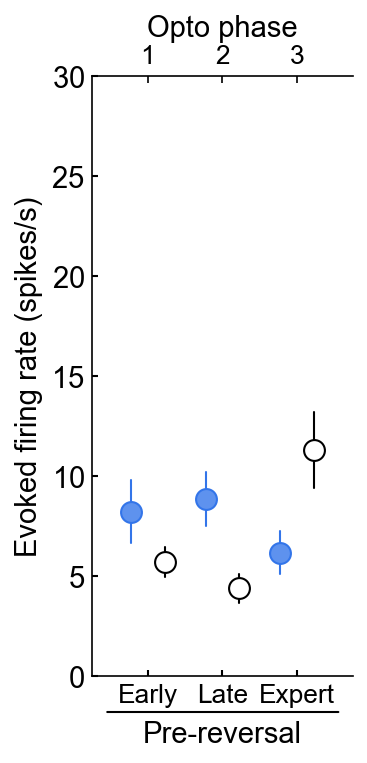

In [14]:
def add_axis_size(fig, ax_w, ax_h, left, bottom):
    fig_w, fig_h = fig.get_size_inches()
    ax = fig.add_axes([left/fig_w, bottom/fig_h, ax_w/fig_w, ax_h/fig_h])
    return ax

def make_axis_size(ax_w, ax_h, left=.3, bottom=.3, right=0, top=0):
    fig_w = (ax_w + left + right) * 1.05
    fig_h = (ax_h + bottom + top) * 1.05
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = add_axis_size(fig, ax_w, ax_h, left, bottom)
    return fig, ax

fig,ax = make_axis_size(1.74, 4, left=.3, bottom=.3, right=0, top=0)
switch_offset = 0
offset_distance = 0.225

################################################################################################################

data = [control_preearly,control_prelate,control_preexpert]
data = [ilep.rmnan(d) for d in data]

#Plot summary
colmaxes = [np.nan]*3
for idx,(column,polarity) in enumerate(zip(data,[-1,-1,-1])):
    eye_color = 'white'
    border_color='k'
    summary_size=100
    summary_width=1
    
    median = np.mean(column)
    Q1 = median - sem(column)
    Q3 = median + sem(column)
    colmaxes[idx] = Q3
    
    ax.scatter([idx+offset_distance+polarity*switch_offset], [median], ec=border_color,fc=eye_color, s=summary_size,lw=summary_width, zorder=10)
    ax.plot([idx+offset_distance+polarity*switch_offset, idx+offset_distance+polarity*switch_offset], [Q1, Q3], c=border_color, lw=summary_width, zorder=9, solid_capstyle='round')
    
medians = [np.mean(col) for col in data]
    
########################################################
data_two = [opto_preearly,opto_prelate,opto_preexpert]
data_two = [ilep.rmnan(d) for d in data_two]

#Plot summary
passive_colmaxes = [np.nan]*3
for idx,(column,polarity) in enumerate(zip(data_two,[-1,-1,-1])):

    border_color=LASER_COLOR
    eye_color=LIGHT_LASER

    summary_size=100
    summary_width=1
    
    median = np.mean(column)
    Q1 = median - sem(column)
    Q3 = median + sem(column)
    passive_colmaxes[idx] = Q3
    
    ax.scatter([idx-offset_distance+polarity*switch_offset], [median], ec=border_color,fc=eye_color, s=summary_size,lw=summary_width, zorder=10,marker='o')
    ax.plot([idx-offset_distance+polarity*switch_offset, idx-offset_distance+polarity*switch_offset], [Q1, Q3], c=border_color, lw=summary_width, zorder=9, solid_capstyle='round')
    
medians = [np.mean(col) for col in data_two]



################################################################################################################

labels = ['Early','Late','Expert']

ax.set_ylim([0,30])
ylab = ax.set_ylabel('Evoked firing rate (spikes/s)')
              
ax.set_xlim([-0.75-switch_offset,2.75+switch_offset])
ax.set_xticks([-0-switch_offset,1-switch_offset,2-switch_offset])
ax.set_xticklabels(labels)
sec_x = ax.secondary_xaxis('top')
sec_x.set_xticks([0-switch_offset,1-switch_offset,2-switch_offset])
sec_x.set_xticklabels(['1','2','3'])
sxlab = sec_x.set_xlabel('Opto phase')

stdyfrac = 0.06
xtick_pos_pre = ax.get_xticks()[1]
Yval = ilep.getPrePostLabelYval(ax.get_ylim(),Yfrac=-2*stdyfrac)
t1 = ax.text(xtick_pos_pre, Yval, 'Pre-reversal', ha='center', va='bottom', fontsize=stdfont,color='k')
ax.annotate('', xy=(0.0425, -stdyfrac), xycoords='axes fraction', xytext=(0.96, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))

ax.tick_params(direction='in', length=3, width=1)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label,sec_x.xaxis.label,t1] +
    ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(stdfont)
for item in (ax.get_xticklabels()):
    item.set_fontsize(stdfont*0.9)
    pass
for item in (sec_x.get_xticklabels()):
    item.set_fontsize(stdfont*0.9)
    pass

ax.scatter([], [], ec=TARGET_COLOR,fc=TARGET_COLOR, s=summary_size,lw=summary_width,marker='o',label='Target')
ax.scatter([], [], ec=NONTARGET_COLOR,fc=NONTARGET_COLOR, s=summary_size,lw=summary_width,marker='o',label='Nontarget')

artists = [ylab,t1,sxlab]

# fig.savefig(os.path.join('..','..','Figures','Figure 3p.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

In [15]:
Xs = [control_preearly,control_prelate,control_preexpert]
Ys = [opto_preearly,opto_prelate,opto_preexpert]
pvals = [0,0,0]
print('Opto ON vs Control\n')

for i,(x,y) in enumerate(zip(Xs,Ys)):
    s,p = ttest_ind(x,y, equal_var=False)
    pvals[i] = p

_,pvals_corr = pg.multicomp(pvals,method='fdr_bh')
print()
print(pvals_corr)

Opto ON vs Control


[0.15568857 0.01076333 0.02942375]
